# ELSA: model progression from Cox PH to Transformer

This notebook mirrors the simulation analysis using the agreed ELSA outcome set:

- **Basic Cox PH** — one separate Cox model per outcome, baseline covariates only.
- **Deep MultiCox NN** — one shared neural network with an outcome-specific Cox partial likelihood.
- **Simple binary time series** — multi-outcome discrete-time hazards with baseline covariates and interval-specific baseline hazards.
- **Transformer** — the same discrete-time multi-outcome hazard target, but with causal attention over accumulated prior disease history.

The primary comparison is **out-of-sample discrimination by outcome**. The Transformer additionally gets a dynamic, interval-by-interval analysis because its purpose is to use longitudinal history.

Death is the final absorbing state. Prevalent disease at study entry is history, not an incident event.


In [ ]:
# Run once if lifelines is not installed in this environment:
%pip install lifelines -q


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from prepare_elsa_models import (
    EVENT_TYPES,
    COVARIATE_COLS,
    prepare_elsa_wide,
    make_simple_binary_timeseries,
    make_transformer,
)

from elsa_model_definitions import (
    split_ids,
    fit_separate_coxph,
    score_separate_coxph,
    cox_coefficient_table,
    fit_multicox_nn,
    score_multicox_nn,
    fit_simple_binary,
    score_simple_binary_baseline,
    fit_transformer,
    score_transformer_at_baseline,
    dynamic_cindex_table,
    cindex_table_from_scores,
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

EVENT_TYPES


['cvd',
 'stroke',
 'hypertension',
 'diabetes',
 'asthma_respir',
 'cancer',
 'arthritis',
 'osteo_hip',
 'mental_health',
 'neuro',
 'cataract',
 'death']

## 1. Load and shape ELSA

Set `file_elsa` to the preprocessed ELSA file produced by the R pipeline. The adapter accepts CSV, pickle, parquet, feather and Excel.

The baseline covariates are fixed to **age, BMI, sex, education and wealth**. Ethnicity is excluded, and hypertension is an outcome rather than a baseline covariate.


In [11]:
# EDIT THIS PATH
file_elsa = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/elsa_data.csv"

wide = prepare_elsa_wide(file_elsa)

print("N =", len(wide))
print("Covariates:", COVARIATE_COLS)
print("Outcomes:", EVENT_TYPES)
wide.head()


N = 11798
Covariates: ['age', 'bmi', 'sex', 'edu', 'wealth']
Outcomes: ['cvd', 'stroke', 'hypertension', 'diabetes', 'asthma_respir', 'cancer', 'arthritis', 'osteo_hip', 'mental_health', 'neuro', 'cataract', 'death']


,id,age,bmi,sex,edu,wealth,exit_dis,exit_death,age_cvd,prevalent_cvd,...,event_neuro,time_neuro,age_cataract,prevalent_cataract,event_cataract,time_cataract,age_death,prevalent_death,event_death,time_death
0,100006,58.08,32.400002,0,1.0,2.333333,61.92,61.92,NaN,0,...,0,3.84,NaN,0,0,3.84,NaN,0,0,3.84
1,100007,57.00,28.610956,0,1.0,2.625000,71.00,71.00,66.0,0,...,0,14.00,62.25,0,1,5.25,NaN,0,0,14.00
2,100009,66.58,31.200001,0,1.0,3.166667,78.75,78.75,NaN,0,...,0,12.17,NaN,0,0,12.17,NaN,0,0,12.17
3,100024,77.75,30.000000,0,2.0,3.000000,81.92,81.92,67.0,1,...,0,4.17,80.92,0,1,3.17,NaN,0,0,4.17
4,100025,76.08,28.135906,0,2.0,4.666667,87.83,87.83,NaN,0,...,0,11.75,NaN,0,0,11.75,NaN,0,0,11.75


In [13]:
# Basic data audit
audit = []
for e in EVENT_TYPES:
    audit.append({
        "event": e,
        "prevalent_n": int(wide[f"prevalent_{e}"].sum()),
        "incident_n": int(wide[f"event_{e}"].sum()),
        "incident_pct_all": 100 * wide[f"event_{e}"].mean(),
        "median_followup_y": wide.loc[wide[f"prevalent_{e}"] == 0, f"time_{e}"].median(),
    })

audit = pd.DataFrame(audit)
audit


,event,prevalent_n,incident_n,incident_pct_all,median_followup_y
0,cvd,1768,1862,15.782336,10.16
1,stroke,340,567,4.805899,10.34
2,hypertension,3701,2244,19.020173,9.59
3,diabetes,765,962,8.153924,10.25
4,asthma_respir,1610,862,7.306323,10.25
5,cancer,700,1156,9.798271,10.25
6,arthritis,3432,1976,16.748601,9.83
7,osteo_hip,450,1125,9.535514,10.25
8,mental_health,837,607,5.144940,10.25
9,neuro,67,338,2.864892,10.41


## 2. Patient-level train/test split

Every model uses the **same people** in training and testing. This is important because the discrete-time data contain multiple rows per person; splitting rows would leak the same participant into both sets.


In [15]:
train_ids, test_ids = split_ids(wide["id"], test_size=0.25, seed=SEED)

train_wide = wide[wide["id"].isin(train_ids)].copy().reset_index(drop=True)
test_wide = wide[wide["id"].isin(test_ids)].copy().reset_index(drop=True)

print("Train:", len(train_wide))
print("Test :", len(test_wide))


Train: 8848
Test : 2950


## 3. Basic Cox PH — separate model for each outcome

Each outcome has its own risk set. Someone with prevalent arthritis is excluded from the arthritis Cox model but can still contribute to the diabetes, cancer, stroke, etc. models if those conditions were not prevalent at entry.


In [17]:
cox_models = fit_separate_coxph(
    train_wide,
    covariates=COVARIATE_COLS,
    event_types=EVENT_TYPES,
)

cox_scores = score_separate_coxph(
    cox_models,
    test_wide,
    covariates=COVARIATE_COLS,
    event_types=EVENT_TYPES,
)

cox_results = cindex_table_from_scores(
    test_wide,
    cox_scores,
    EVENT_TYPES,
    model_name="Basic Cox",
)

cox_results


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Basic Cox,2515,461,0.619004
1,stroke,Basic Cox,2853,147,0.735992
2,hypertension,Basic Cox,1990,521,0.625488
3,diabetes,Basic Cox,2761,255,0.684289
4,asthma_respir,Basic Cox,2554,228,0.618683
5,cancer,Basic Cox,2790,287,0.583075
6,arthritis,Basic Cox,2076,488,0.601093
7,osteo_hip,Basic Cox,2825,288,0.722287
8,mental_health,Basic Cox,2720,158,0.607043
9,neuro,Basic Cox,2937,80,0.803770


In [18]:
# Coefficients / hazard ratios for inspection
cox_coef = cox_coefficient_table(cox_models)
cox_coef.head(20)


,event,covariate,coef,hazard_ratio,se,p
0,cvd,age,0.045682,1.046742,0.003044,6.471860e-51
1,cvd,bmi,0.027786,1.028176,0.004918,1.608649e-08
2,cvd,sex,-0.214110,0.807260,0.054191,7.782140e-05
3,cvd,edu,0.082518,1.086019,0.045123,6.744137e-02
4,cvd,wealth,-0.103603,0.901584,0.022814,5.591788e-06
5,stroke,age,0.064050,1.066146,0.005425,3.592129e-32
6,stroke,bmi,0.000360,1.000360,0.009609,9.701469e-01
7,stroke,sex,-0.333431,0.716461,0.098746,7.337495e-04
8,stroke,edu,-0.089827,0.914089,0.084271,2.864542e-01
9,stroke,wealth,-0.129286,0.878723,0.041859,2.010976e-03


## 4. Deep multi-outcome Cox NN

This is the main ELSA adaptation to the original simulation class. The original MultiCox code assumes everybody is eligible for every outcome. In ELSA that is not true because many participants have prevalent disease at entry.

Here, each outcome has its **own prevalence mask inside the Cox loss**, so we do not need to discard a participant merely because a different disease was already present.


In [21]:
multicox_model, multicox_scaler, multicox_loss = fit_multicox_nn(
    train_wide,
    covariates=COVARIATE_COLS,
    event_types=EVENT_TYPES,
    hidden_dims=(64, 32),
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=500,
    verbose_every=50,
    seed=SEED,
)

multicox_scores = score_multicox_nn(
    multicox_model,
    multicox_scaler,
    test_wide,
    COVARIATE_COLS,
)

multicox_results = cindex_table_from_scores(
    test_wide,
    multicox_scores,
    EVENT_TYPES,
    model_name="Deep MultiCox",
)

multicox_results


MultiCox epoch    1/500: loss=8.5589
MultiCox epoch   50/500: loss=8.3894
MultiCox epoch  100/500: loss=8.3423
MultiCox epoch  150/500: loss=8.3311
MultiCox epoch  200/500: loss=8.3290
MultiCox epoch  250/500: loss=8.3254
MultiCox epoch  300/500: loss=8.3197
MultiCox epoch  350/500: loss=8.3191
MultiCox epoch  400/500: loss=8.3166
MultiCox epoch  450/500: loss=8.3098
MultiCox epoch  500/500: loss=8.3093


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Deep MultiCox,2515,461,0.614840
1,stroke,Deep MultiCox,2853,147,0.726734
2,hypertension,Deep MultiCox,1990,521,0.631655
3,diabetes,Deep MultiCox,2761,255,0.678852
4,asthma_respir,Deep MultiCox,2554,228,0.636859
5,cancer,Deep MultiCox,2790,287,0.581073
6,arthritis,Deep MultiCox,2076,488,0.599493
7,osteo_hip,Deep MultiCox,2825,288,0.728611
8,mental_health,Deep MultiCox,2720,158,0.600233
9,neuro,Deep MultiCox,2937,80,0.793256


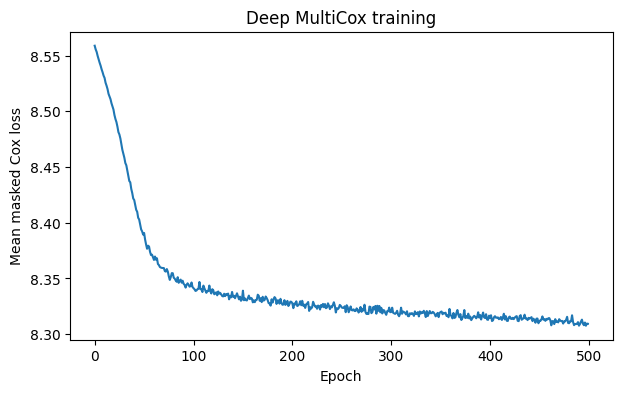

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(multicox_loss)
plt.xlabel("Epoch")
plt.ylabel("Mean masked Cox loss")
plt.title("Deep MultiCox training")
plt.show()


## 5. Simple binary time-series model

This keeps the comparison deliberately simple: baseline covariates only, repeated over the discrete 2-year intervals, with an event-specific baseline hazard for each interval.

It **does not receive prior disease history as a feature**. That leaves the longitudinal-history advantage to the Transformer and makes the model progression easier to interpret.


In [40]:
import importlib
import prepare_elsa_models

importlib.reload(prepare_elsa_models)

from prepare_elsa_models import (
    EVENT_TYPES,
    COVARIATE_COLS,
    prepare_elsa_wide,
    make_simple_binary_timeseries,
    make_transformer,
)

In [42]:
INTERVAL_YEARS = 2.0

train_long_binary, binary_features = make_simple_binary_timeseries(
    train_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=COVARIATE_COLS,
    include_history=False,
)

test_long_binary, _ = make_simple_binary_timeseries(
    test_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=COVARIATE_COLS,
    include_history=False,
)

print(train_long_binary.shape, test_long_binary.shape)
print("Features:", binary_features)


(79632, 48) (26550, 48)
Features: ['age', 'bmi', 'sex', 'edu', 'wealth']


In [44]:
binary_model, binary_scaler, binary_loss = fit_simple_binary(
    train_long_binary,
    features=binary_features,
    event_types=EVENT_TYPES,
    hidden_dims=(64, 32),
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=150,
    batch_size=1024,
    verbose_every=20,
    seed=SEED,
)

binary_scores = score_simple_binary_baseline(
    binary_model,
    binary_scaler,
    test_wide,
    binary_features,
)

binary_results = cindex_table_from_scores(
    test_wide,
    binary_scores,
    EVENT_TYPES,
    model_name="Binary time series",
)

binary_results


Binary TS epoch    1/150: loss=0.4128
Binary TS epoch   20/150: loss=0.0990
Binary TS epoch   40/150: loss=0.0978
Binary TS epoch   60/150: loss=0.0970
Binary TS epoch   80/150: loss=0.0969
Binary TS epoch  100/150: loss=0.0966
Binary TS epoch  120/150: loss=0.0964
Binary TS epoch  140/150: loss=0.0963


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Binary time series,2515,461,0.617464
1,stroke,Binary time series,2853,147,0.740239
2,hypertension,Binary time series,1990,521,0.633507
3,diabetes,Binary time series,2761,255,0.676736
4,asthma_respir,Binary time series,2554,228,0.628861
5,cancer,Binary time series,2790,287,0.581717
6,arthritis,Binary time series,2076,488,0.597112
7,osteo_hip,Binary time series,2825,288,0.731814
8,mental_health,Binary time series,2720,158,0.604957
9,neuro,Binary time series,2937,80,0.797141


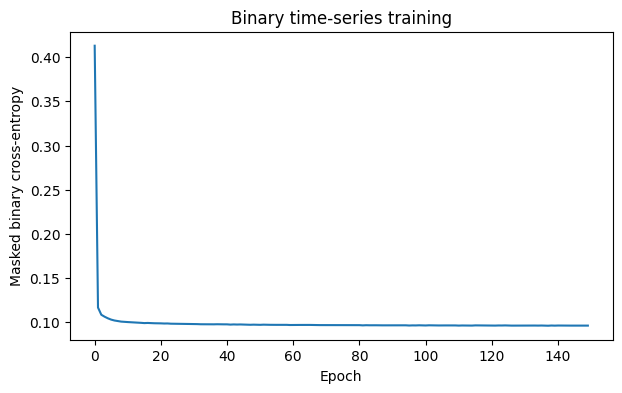

In [45]:
plt.figure(figsize=(7, 4))
plt.plot(binary_loss)
plt.xlabel("Epoch")
plt.ylabel("Masked binary cross-entropy")
plt.title("Binary time-series training")
plt.show()


## 6. Transformer

The Transformer receives the same baseline covariates plus `prev_<event>` indicators. These indicators contain only disease history known **before** the current interval, so the model cannot see an event in the same interval that it is trying to predict.

The Transformer uses the same masked binary survival loss as the simple time-series model. This makes the architectural comparison relatively clean: the major addition is causal sequence modelling of disease history.


In [48]:
train_long_tr, transformer_features = make_transformer(
    train_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=COVARIATE_COLS,
    include_prev_features=True,
    as_torch=False,
)

test_long_tr, _ = make_transformer(
    test_wide,
    interval_years=INTERVAL_YEARS,
    event_types=EVENT_TYPES,
    covariates=COVARIATE_COLS,
    include_prev_features=True,
    as_torch=False,
)

print("Transformer features:")
print(transformer_features)
print("Train long:", train_long_tr.shape)


Transformer features:
['age', 'bmi', 'sex', 'edu', 'wealth', 'prev_cvd', 'prev_stroke', 'prev_hypertension', 'prev_diabetes', 'prev_asthma_respir', 'prev_cancer', 'prev_arthritis', 'prev_osteo_hip', 'prev_mental_health', 'prev_neuro', 'prev_cataract']
Train long: (79632, 48)


In [49]:
transformer_model, transformer_loss = fit_transformer(
    train_long_tr,
    features=transformer_features,
    event_types=EVENT_TYPES,
    d_model=64,
    nhead=4,
    nlayers=2,
    dropout=0.10,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=100,
    batch_size=128,
    verbose_every=10,
    seed=SEED,
)


C:\Users\dinab\anaconda3\envs\studio1\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Transformer epoch    1/100: loss=0.1422
Transformer epoch   10/100: loss=0.0957
Transformer epoch   20/100: loss=0.0948
Transformer epoch   30/100: loss=0.0943
Transformer epoch   40/100: loss=0.0934
Transformer epoch   50/100: loss=0.0923
Transformer epoch   60/100: loss=0.0907
Transformer epoch   70/100: loss=0.0888
Transformer epoch   80/100: loss=0.0870
Transformer epoch   90/100: loss=0.0849
Transformer epoch  100/100: loss=0.0831
Causality check passed: intervals >= 4 do not affect earlier logits.


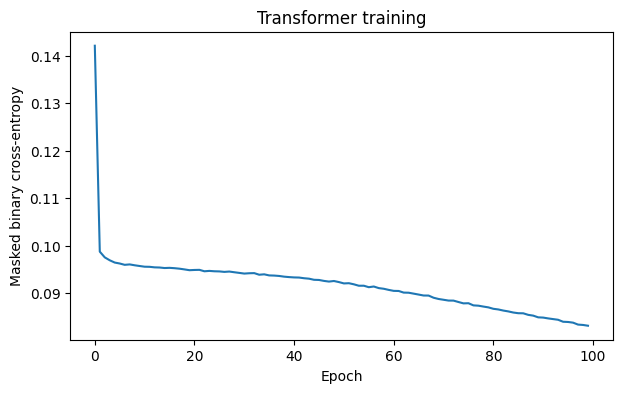

In [51]:
plt.figure(figsize=(7, 4))
plt.plot(transformer_loss)
plt.xlabel("Epoch")
plt.ylabel("Masked binary cross-entropy")
plt.title("Transformer training")
plt.show()


### Baseline Transformer comparison

For the headline C-index comparison below, the Transformer is scored at **interval 0**. It can use prevalent disease history available at entry, but not future diagnoses.

This is not exactly the same information set as the baseline-only Cox/MultiCox/binary models, so the table should be interpreted as a model-progression comparison rather than a strict architecture-only experiment.


In [54]:
transformer_scores, transformer_ids = score_transformer_at_baseline(
    transformer_model,
    test_long_tr,
    transformer_features,
    EVENT_TYPES,
)

# Align wide table to the sequence order.
test_wide_tr = test_wide.set_index("id").loc[transformer_ids].reset_index()

transformer_results = cindex_table_from_scores(
    test_wide_tr,
    transformer_scores,
    EVENT_TYPES,
    model_name="Transformer",
)

transformer_results


,event,model,n_test_at_risk,n_test_events,c_index
0,cvd,Transformer,2515,461,0.579506
1,stroke,Transformer,2853,147,0.630185
2,hypertension,Transformer,1990,521,0.590302
3,diabetes,Transformer,2761,255,0.647514
4,asthma_respir,Transformer,2554,228,0.586731
5,cancer,Transformer,2790,287,0.560587
6,arthritis,Transformer,2076,488,0.578774
7,osteo_hip,Transformer,2825,288,0.635790
8,mental_health,Transformer,2720,158,0.572147
9,neuro,Transformer,2937,80,0.681312


## 7. Headline model comparison


In [58]:
results_long = pd.concat(
    [cox_results, multicox_results, binary_results, transformer_results],
    ignore_index=True,
)

results = results_long.pivot(index="event", columns="model", values="c_index")
results = results.loc[EVENT_TYPES]
results.round(3)


model,Basic Cox,Binary time series,Deep MultiCox,Transformer
event,,,,
cvd,0.619,0.617,0.615,0.580
stroke,0.736,0.740,0.727,0.630
hypertension,0.625,0.634,0.632,0.590
diabetes,0.684,0.677,0.679,0.648
asthma_respir,0.619,0.629,0.637,0.587
cancer,0.583,0.582,0.581,0.561
arthritis,0.601,0.597,0.599,0.579
osteo_hip,0.722,0.732,0.729,0.636
mental_health,0.607,0.605,0.600,0.572


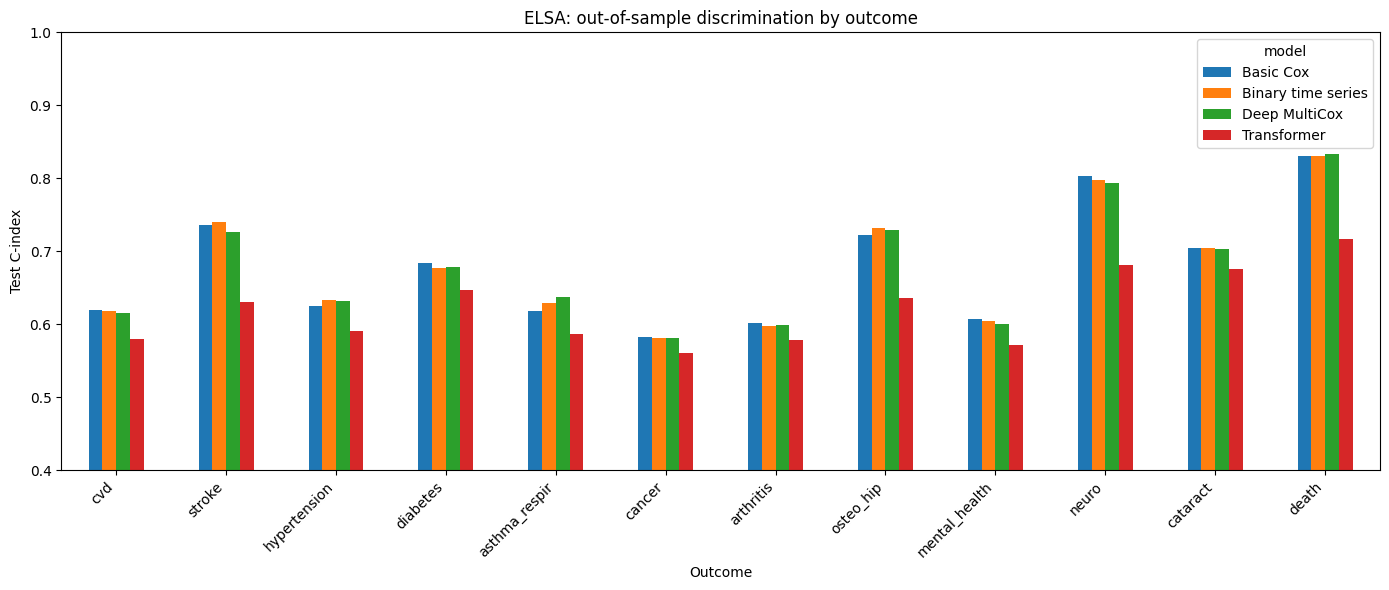

In [60]:
ax = results.plot(kind="bar", figsize=(14, 6))
ax.set_ylabel("Test C-index")
ax.set_xlabel("Outcome")
ax.set_ylim(0.4, 1.0)
ax.set_title("ELSA: out-of-sample discrimination by outcome")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 8. Dynamic Transformer analysis

The simulation work also asks whether the more complex model gains when actual history becomes available. For ELSA, the natural analogue is to assess prediction at each 2-year interval among people still at risk.

Because the target within one interval is binary, this section reports **interval-specific AUC**, not a time-to-event C-index.


In [62]:
transformer_dynamic = dynamic_cindex_table(
    transformer_model,
    test_long_tr,
    transformer_features,
    EVENT_TYPES,
)

transformer_dynamic.head(20)


,interval,event,n_at_risk,n_events,auc
0,0,cvd,2515,90,0.608110
1,0,stroke,2853,21,0.667121
2,0,hypertension,1990,148,0.590864
3,0,diabetes,2761,38,0.560798
4,0,asthma_respir,2554,56,0.577348
5,0,cancer,2790,42,0.557219
6,0,arthritis,2076,108,0.626656
7,0,osteo_hip,2825,51,0.619216
8,0,mental_health,2720,43,0.565984
9,0,neuro,2937,9,0.806011


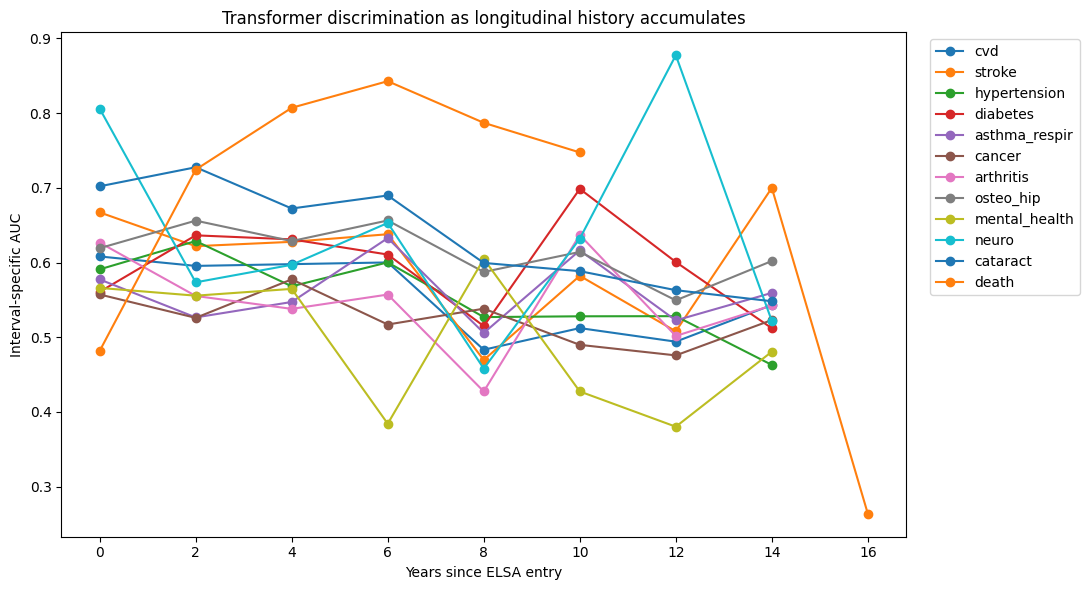

In [63]:
# AUC trajectories by outcome
auc_wide = transformer_dynamic.pivot(index="interval", columns="event", values="auc")

plt.figure(figsize=(11, 6))
for e in EVENT_TYPES:
    plt.plot(
        auc_wide.index * INTERVAL_YEARS,
        auc_wide[e],
        marker="o",
        label=e,
    )
plt.xlabel("Years since ELSA entry")
plt.ylabel("Interval-specific AUC")
plt.title("Transformer discrimination as longitudinal history accumulates")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 9. Event counts and interpretation checks

Before interpreting differences between models, inspect event counts. Rare outcomes can produce unstable C-indices/AUCs, and the Transformer has substantially more parameters than the Cox models.

The ELSA analysis is observational prediction. Differences in Transformer logits after a prior diagnosis should be described as **predictive temporal associations**, not causal effects.


In [67]:
comparison_with_counts = (
    results_long
    .pivot_table(
        index=["event", "n_test_at_risk", "n_test_events"],
        columns="model",
        values="c_index",
    )
    .reset_index()
)

comparison_with_counts


model,event,n_test_at_risk,n_test_events,Basic Cox,Binary time series,Deep MultiCox,Transformer
0,arthritis,2076,488,0.601093,0.597112,0.599493,0.578774
1,asthma_respir,2554,228,0.618683,0.628861,0.636859,0.586731
2,cancer,2790,287,0.583075,0.581717,0.581073,0.560587
3,cataract,2695,865,0.703979,0.704083,0.702469,0.676265
4,cvd,2515,461,0.619004,0.617464,0.614840,0.579506
5,death,2950,273,0.830051,0.830528,0.832792,0.716872
6,diabetes,2761,255,0.684289,0.676736,0.678852,0.647514
7,hypertension,1990,521,0.625488,0.633507,0.631655,0.590302
8,mental_health,2720,158,0.607043,0.604957,0.600233,0.572147
9,neuro,2937,80,0.803770,0.797141,0.793256,0.681312


## 10. Save outputs


In [70]:
results_long.to_csv("elsa_model_cindex_results.csv", index=False)
cox_coef.to_csv("elsa_cox_coefficients.csv", index=False)
transformer_dynamic.to_csv("elsa_transformer_dynamic_auc.csv", index=False)

torch.save(multicox_model.state_dict(), "elsa_multicox.pt")
torch.save(binary_model.state_dict(), "elsa_binary_timeseries.pt")
torch.save(transformer_model.state_dict(), "elsa_transformer.pt")

print("Saved result tables and PyTorch model state dictionaries.")


Saved result tables and PyTorch model state dictionaries.
